In [1]:
import sys
import os
from pathlib import Path

# add the project to python path so that we can import src
cwd = Path().resolve()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0,str(project_root))


In [2]:
from agent.index import create_simple_custom_agent

/Users/amruthakaruturi/Desktop/AIVIO/server/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/amruthakaruturi/Desktop/AIVIO/server/venv/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
chat_history = []

message_content =  "Had a quick sync with Dr. Reddy regarding Product Y's safety profile. They noted fewer patient complaints compared to the older line. Shared the updated clinical trial printout and agreed to reconnect in two weeks."
agent = create_simple_custom_agent(chat_history)

result = await agent.ainvoke({
    "messages": [
        {"role": "user", "content": message_content}
    ]
})

result

chat_history:  []
system_prompt:  
You are an AI assistant that controls an HCP interaction form.

The user must NOT manually fill the form. 
All form updates must happen through tool calls.

Current date: 2026-07-09

Your responsibilities:
1. Understand the user's natural language input.
2. Select the correct tool.
3. Extract structured form data.
4. Update only the fields the user mentioned.
5. Preserve existing values unless the user explicitly corrects them.
6. Never invent missing information.
7. Ask a short clarification only if required.

Available form fields:
- hcp_name
- interaction_type
- interaction_date
- interaction_time
- attendees
- materials_shared
- samples_distributed
- hcp_sentiment: positive, neutral, negative
- outcomes
- follow_up_actions

Tool usage rules:
- Use log_interaction_tool when the user describes a new interaction.
- Use edit_interaction_tool when the user corrects or changes existing details.
- Use add_materials_samples_tool when the user mentions bro

{'messages': [HumanMessage(content="Had a quick sync with Dr. Reddy regarding Product Y's safety profile. They noted fewer patient complaints compared to the older line. Shared the updated clinical trial printout and agreed to reconnect in two weeks.", additional_kwargs={}, response_metadata={}, id='3b4b2902-1233-433d-9726-431d89655a93'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ddsjjxam8', 'function': {'arguments': '{"message":"Had a quick sync with Dr. Reddy regarding Product Y\'s safety profile. They noted fewer patient complaints compared to the older line. Shared the updated clinical trial printout and agreed to reconnect in two weeks."}', 'name': 'log_interaction_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 697, 'total_tokens': 752, 'completion_time': 0.115825772, 'completion_tokens_details': None, 'prompt_time': 0.063701974, 'prompt_tokens_details': None, 'queue_time': 0.056866095, 'total_tim

In [4]:
result

{'messages': [HumanMessage(content="Had a quick sync with Dr. Reddy regarding Product Y's safety profile. They noted fewer patient complaints compared to the older line. Shared the updated clinical trial printout and agreed to reconnect in two weeks.", additional_kwargs={}, response_metadata={}, id='3b4b2902-1233-433d-9726-431d89655a93'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ddsjjxam8', 'function': {'arguments': '{"message":"Had a quick sync with Dr. Reddy regarding Product Y\'s safety profile. They noted fewer patient complaints compared to the older line. Shared the updated clinical trial printout and agreed to reconnect in two weeks."}', 'name': 'log_interaction_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 697, 'total_tokens': 752, 'completion_time': 0.115825772, 'completion_tokens_details': None, 'prompt_time': 0.063701974, 'prompt_tokens_details': None, 'queue_time': 0.056866095, 'total_tim

In [3]:
chat_history = []

message_content =  "Had a quick sync with Dr. Reddy regarding Product Y's safety profile. They noted fewer patient complaints compared to the older line. Shared the updated clinical trial printout and agreed to reconnect in two weeks."
agent = create_simple_custom_agent(chat_history)

system_prompt:  
You are an AI assistant that controls an HCP interaction form.

The user must NOT manually fill the form.
All form updates must happen through tool calls.

Current date: 2026-07-10
Current time: 11:01

Responsibilities:
1. Understand the user's natural language input.
2. Select the correct tool.
3. Extract structured form data.
4. Update only fields the user mentioned or fields required by date/time default rules.
5. Preserve existing values unless the user explicitly corrects them.
6. Never invent missing information except date/time defaults described below.

Date/time default rules:
- If the user provides no date and no time, set:
  - interaction_date = current date
  - interaction_time = current time
- If the user provides a date but no time, set:
  - interaction_date = provided date
  - interaction_time = current time
- If the user provides a time but no date, set:
  - interaction_date = current date
  - interaction_time = provided time
- Convert relative dates li

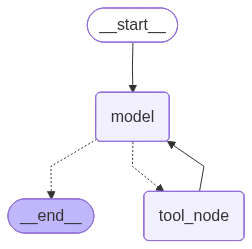

In [4]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
display(
    Image(
        agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)